In [1]:

# Para manipulación y análisis de datos
!pip install pandas pymongo

# Para visualización de datos (gráficas)
!pip install matplotlib seaborn

# Opcional: Para análisis de sentimiento y lenguaje (muy cool para Andrés)
!pip install textblob

# Instalamos la versión CPU para ahorrar espacio
!pip install torch --index-url https://download.pytorch.org/whl/cpu
# Luego el resto
!pip install sentence-transformers scikit-learn scipy

!pip install ipympl
!pip install squarify
%matplotlib widget

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pymongo import MongoClient
import pandas as pd
import seaborn as sns
import numpy as np
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

## Obtención de datos
Se toman los datos obtenidos y guardados en la base de datos con el fin de iniciar el análisis

In [3]:
# Conexión al servicio de MongoDB
client = MongoClient('mongodb://mongodb:27017/')
db = client['social_analytics']
collections = db.list_collection_names()
print("🗄️ Colecciones encontradas en 'social_analytics':")
for c in collections:
    # Contamos cuántos documentos hay en cada una para darle más info a Andrés
    count = db[c].count_documents({})
    print(f" - {c} ({count} documentos)")



🗄️ Colecciones encontradas en 'social_analytics':
 - tweets (18701 documentos)


In [4]:
collection = db['tweets']
# Convertir la colección a DataFrame
df = pd.DataFrame(list(collection.find()))

# Verificar si cargó algo
if df.empty:
    print("⚠️ El DataFrame está vacío. ¡Revisa si el Cron ya guardó algo!")
else:
    print(f"✅ Éxito: {len(df)} registros cargados en 'df'.")

# Ver una muestra de los datos
display(df)

✅ Éxito: 18701 registros cargados en 'df'.


,_id,tweet_id,account_label,author,content,timestamp_detected,timestamp_posted
0,69d6d770d4b5be3196616259,2041660134846558664,Gamer_Project,@penikmat_hujann,What the fuck just happened?,2026-04-08T22:32:16.245440,2026-04-08T22:32:16.245427
1,69d6d770d4b5be319661625a,2041795685754818669,marthasteward295,@KoruturkBey,"In Canada, a streamer nicknamed Joker was raid...",2026-04-09T04:15:51.378691,2026-04-09T04:15:51.378666
2,69d6d770d4b5be319661625b,2041802128994275586,marthasteward295,@Kaliza_queen,This video say a lot about nowadays society......,2026-04-09T07:58:02.429904,2026-04-09T07:58:02.429891
3,69d6d770d4b5be319661625c,analytics,animecol300_Project,@Maventrading,Your wallet will thank you. New lower pricing...,2026-04-15T22:36:47.360559,2026-04-15T22:36:47.360548
4,69d6d770d4b5be319661625d,2041954231817769138,Gamer_Project,@TheNetDaily,Jake Paul Got Caught,2026-04-08T22:51:53.851682,2026-04-08T22:51:53.851668
...,...,...,...,...,...,...,...
18696,69e012ffaf40d1c27c700e1c,2044346904558047689,animecol300_Project,@kmnm_1403,hope,2026-04-15T22:36:47.429197,2026-04-15T22:36:47.429185
18697,69e012ffaf40d1c27c700e1d,2044250381728002556,animecol300_Project,@bighwanjang1,I just can’t understand why pigeons act like t...,2026-04-15T22:36:47.503721,2026-04-15T22:36:47.503704
18698,69e01309af40d1c27c700e1e,2044414804803154361,marthasteward295,@azuulbenitez_,"The dream I have, you neglect me for 5 seconds...",2026-04-15T22:36:57.629570,2026-04-15T22:36:57.629558
18699,69e01309af40d1c27c700e1f,2044518745326919829,marthasteward295,@realmadrid,89' | 3-3 | Goal by Luis Díaz.,2026-04-15T22:36:57.750382,2026-04-15T22:36:57.750369


Se hace una exploración inicial de los datos para identificar cuales son las cuentas de las que más se reciben tweets, se evidencia que a pesar de que ninguna cuenta sigue a @elonmusk se ve que las cuentas reciben tweets de él.

📊 Resumen de recolección por día:


account_label,Gamer_Project,animecol300_Project,marthasteward295
fecha,,,
2026-04-08,13,13,0
2026-04-09,716,1275,1180
2026-04-10,892,1121,704
2026-04-11,770,1155,905
2026-04-12,748,827,800
2026-04-13,659,647,592
2026-04-14,733,1058,804
2026-04-15,955,1027,1107


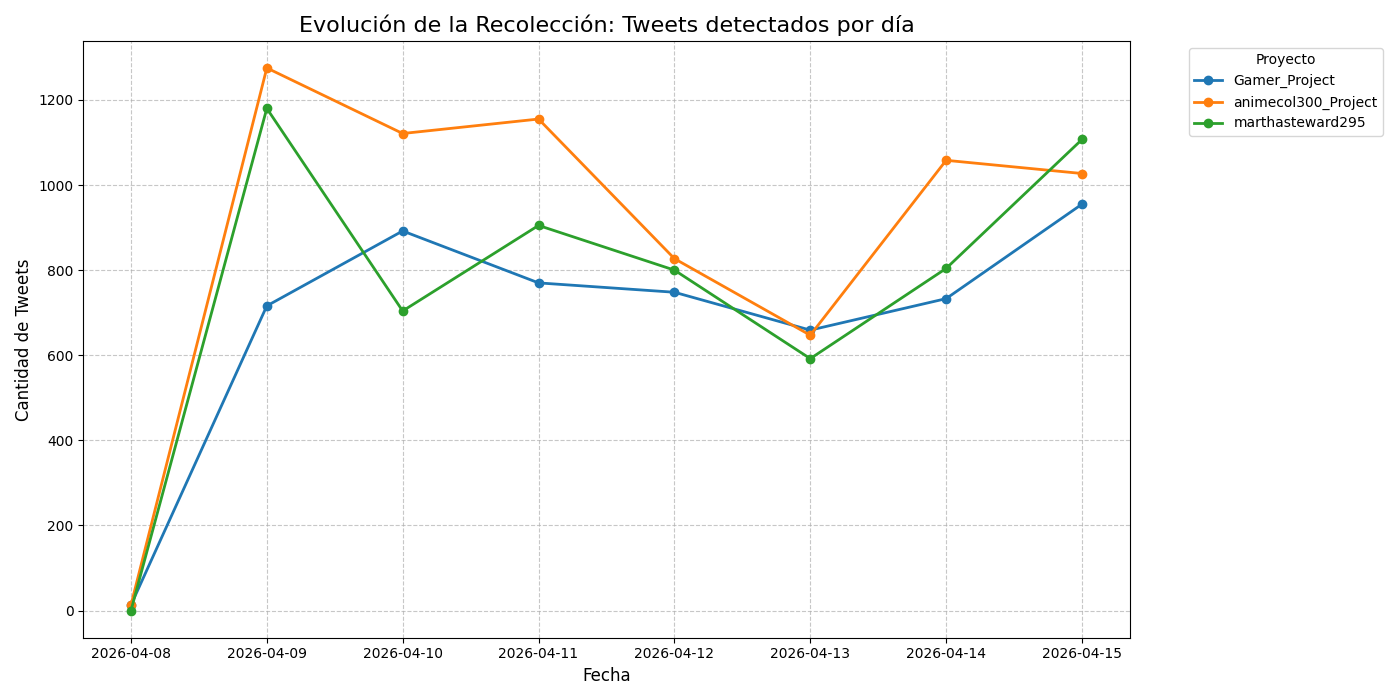

In [5]:

# 1. Convertir la columna de tiempo a formato de fecha real

df['fecha'] = pd.to_datetime(df['timestamp_posted']).dt.date



# 2. Crear el consolidado: Contar tweets por día y por cuenta

consolidado_diario = df.groupby(['fecha', 'account_label']).size().unstack(fill_value=0)



# 3. Mostrar la tabla en el Notebook

print("📊 Resumen de recolección por día:")

display(consolidado_diario)



# 4. Graficar la evolución temporal

plt.figure(figsize=(14, 7))

consolidado_diario.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2)



plt.title('Evolución de la Recolección: Tweets detectados por día', fontsize=16)

plt.xlabel('Fecha', fontsize=12)

plt.ylabel('Cantidad de Tweets', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(title='Proyecto', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

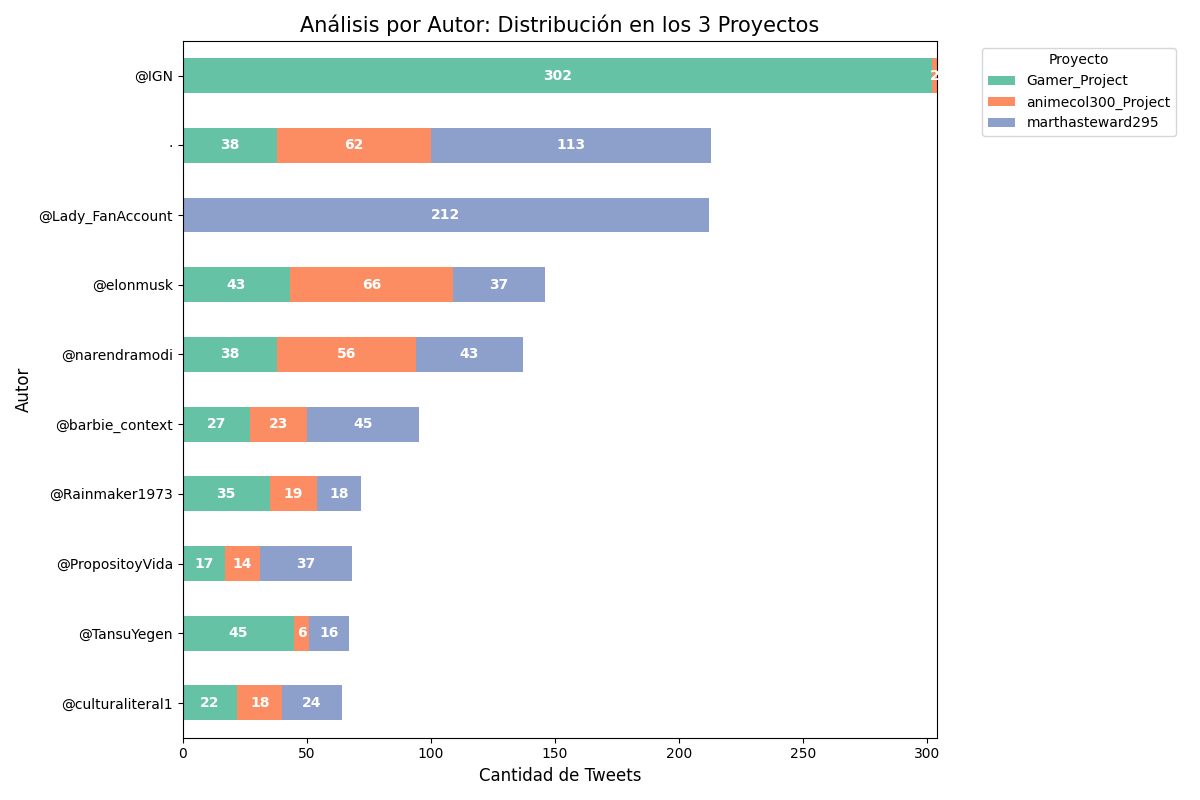

In [6]:
# 1. Filtramos los Top 10 autores
top_10_names = df['author'].value_counts().head(10).index
df_top = df[df['author'].isin(top_10_names)]

# 2. Creamos el pivot
pivot_df = df_top.groupby(['author', 'account_label']).size().unstack(fill_value=0)

# 3. Ordenar por total
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('total', ascending=True).drop(columns='total')

num_proyectos = len(pivot_df.columns)
colores_proyecto = sns.color_palette("Set2", num_proyectos)

# 4. Graficamos con la nueva paleta
ax = pivot_df.plot(kind='barh', stacked=True, figsize=(12, 8), color=colores_proyecto)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(x, y, f'{int(width)}', ha='center', va='center', color='white', fontweight='bold')

plt.title('Análisis por Autor: Distribución en los 3 Proyectos', fontsize=15)
plt.xlabel('Cantidad de Tweets', fontsize=12)
plt.ylabel('Autor', fontsize=12)
plt.legend(title='Proyecto', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

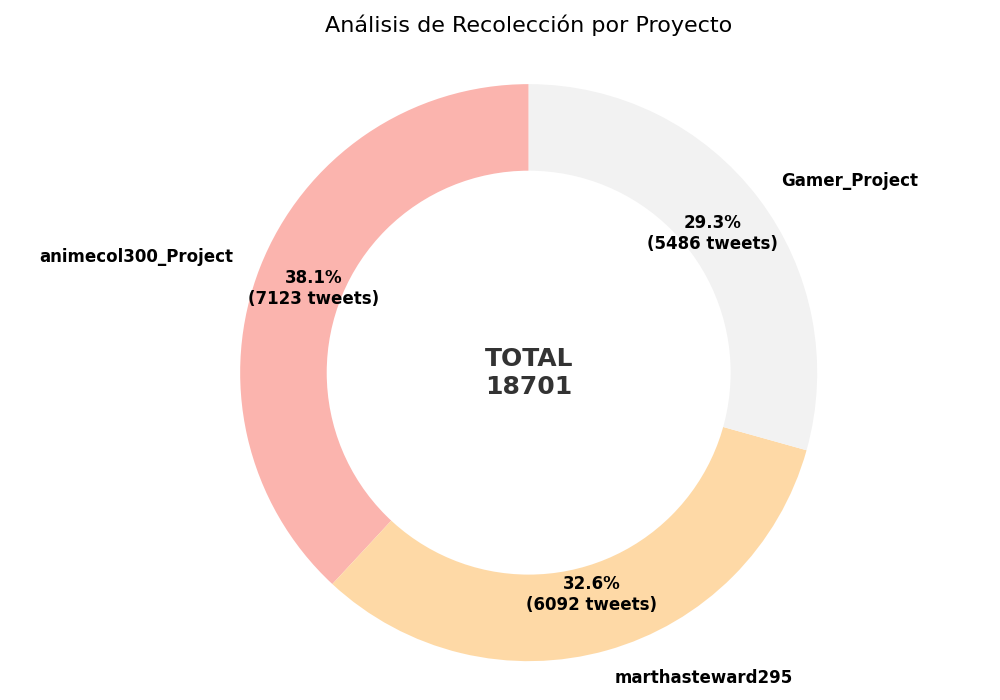

In [7]:
# 1. Preparar los datos
conteo = df['account_label'].value_counts()
total_tweets = conteo.sum()

# 2. Generar los colores manualmente (solución al error TypeError)
# Usamos el mapa de colores 'Pastel1' basado en la cantidad de categorías que tengamos
colores = plt.get_cmap('Pastel1')(np.linspace(0, 1, len(conteo)))

# 3. Función para mostrar porcentaje y cantidad
def fmt_cantidad(pct):
    absolute = int(round(pct/100.*total_tweets))
    return f"{pct:.1f}%\n({absolute} tweets)"

plt.figure(figsize=(10, 7))

# 4. Dibujar la torta (ahora usamos 'colors' en lugar de 'cmap')
plt.pie(conteo, labels=conteo.index, autopct=fmt_cantidad, 
        startangle=90, colors=colores, pctdistance=0.80,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

# 5. Dibujar el círculo blanco central para que sea una DONA
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

# 6. Poner el gran TOTAL en el centro de la dona
plt.text(0, 0, f'TOTAL\n{total_tweets}', ha='center', va='center', 
         fontsize=18, fontweight='bold', color='#333333')

plt.title('Análisis de Recolección por Proyecto', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

## Procesamiento de texto a vectores (Embeddings)
Convertir el contenido de los tweets en números.


In [8]:


# 1. Cargamos el modelo (el mismo que citaron en su artículo)
model = SentenceTransformer("all-MiniLM-L6-v2")

# 2. Tomamos los textos de nuestra base de datos (df['content'])
textos = df['content'].fillna("").tolist()

# 3. ¡MAGIA! Convertimos los 164 tweets en vectores
# Cada tweet ahora es una lista de 384 números
embeddings = model.encode(textos)

print(f"✅ Hemos convertido {len(embeddings)} tweets en vectores de dimensión {embeddings.shape[1]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Hemos convertido 18701 tweets en vectores de dimensión 384


In [9]:
print(embeddings)

[[-0.05179118  0.00033369  0.0511012  ... -0.00082497  0.05301495
   0.01868276]
 [-0.06202882  0.00303204 -0.06478949 ...  0.05405934 -0.01374433
   0.0125442 ]
 [-0.04360653 -0.01821359 -0.10178803 ... -0.01710293  0.11621358
  -0.02902644]
 ...
 [ 0.04777185  0.03687554  0.10301564 ...  0.02867749 -0.07525656
  -0.05644256]
 [-0.05748392  0.14526603 -0.11338845 ...  0.02179546  0.01357251
  -0.04314728]
 [ 0.04922028 -0.05184516  0.01182573 ...  0.0649252  -0.08427201
  -0.02250161]]


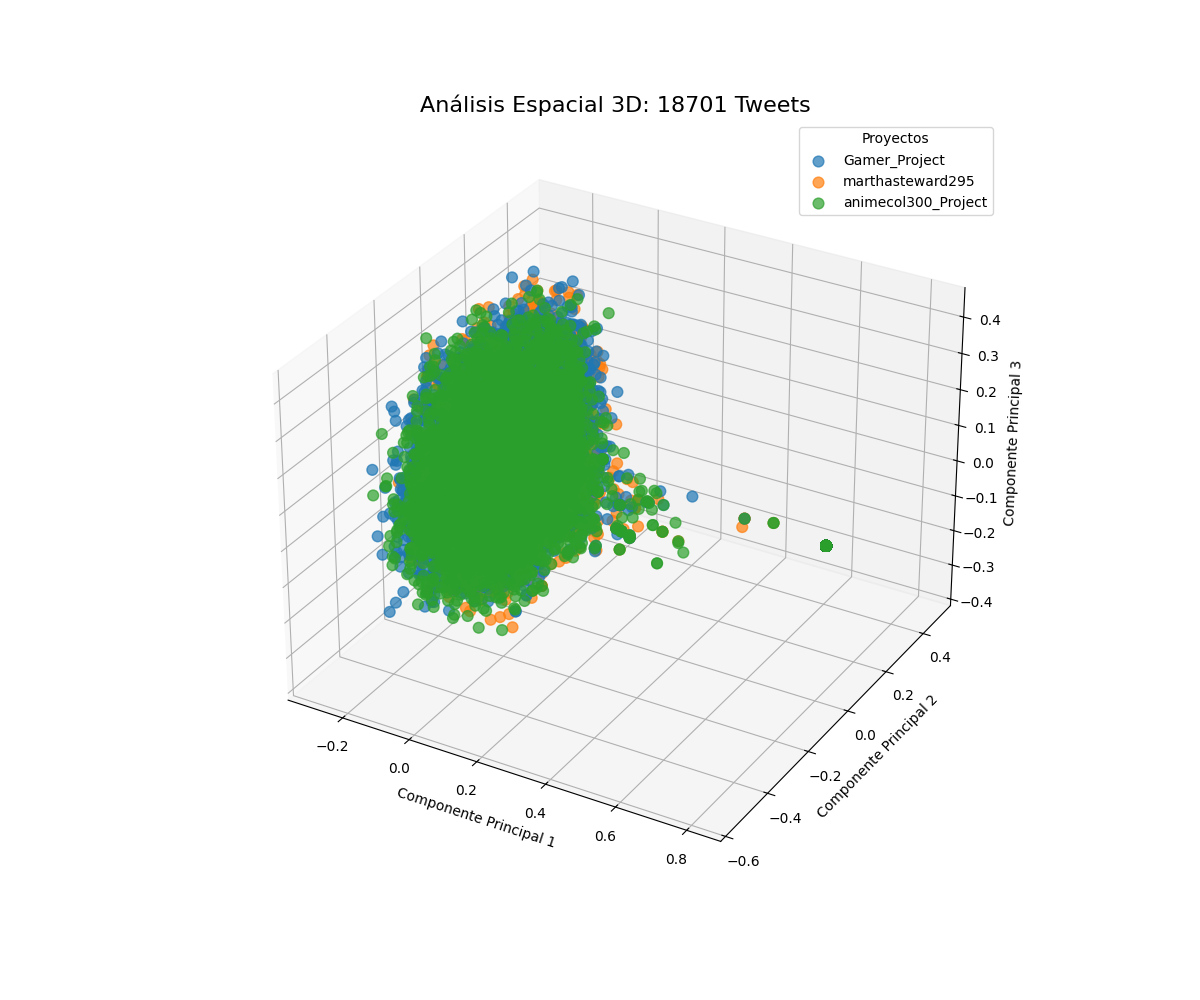

In [10]:
%matplotlib notebook
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from mpl_toolkits.mplot3d import Axes3D



# 1. Reducir a 3 dimensiones (PCA)

pca_3d = PCA(n_components=3)

coords_3d = pca_3d.fit_transform(embeddings)

df['x_3d'] = coords_3d[:, 0]

df['y_3d'] = coords_3d[:, 1]

df['z_3d'] = coords_3d[:, 2]



# 2. Configurar la figura 3D

fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(111, projection='3d')



# 3. Mapear colores por Cluster para mantener la lógica anterior

# (O puedes cambiar 'hue' a 'account_label' si quieres ver los proyectos por color)

categorias = df['account_label'].unique()

colores = ['#5d2a80', '#2a805d', '#ff7f0e'] # Un color por cada cuenta



for i, cuenta in enumerate(categorias):

    subset = df[df['account_label'] == cuenta]

    ax.scatter(subset['x_3d'], subset['y_3d'], subset['z_3d'], 

               label=cuenta, s=60, alpha=0.7)



# 4. Etiquetas de los ejes

ax.set_title(f'Análisis Espacial 3D: {len(df)} Tweets', fontsize=16)

ax.set_xlabel('Componente Principal 1')

ax.set_ylabel('Componente Principal 2')

ax.set_zlabel('Componente Principal 3')



ax.legend(title="Proyectos")

plt.show()

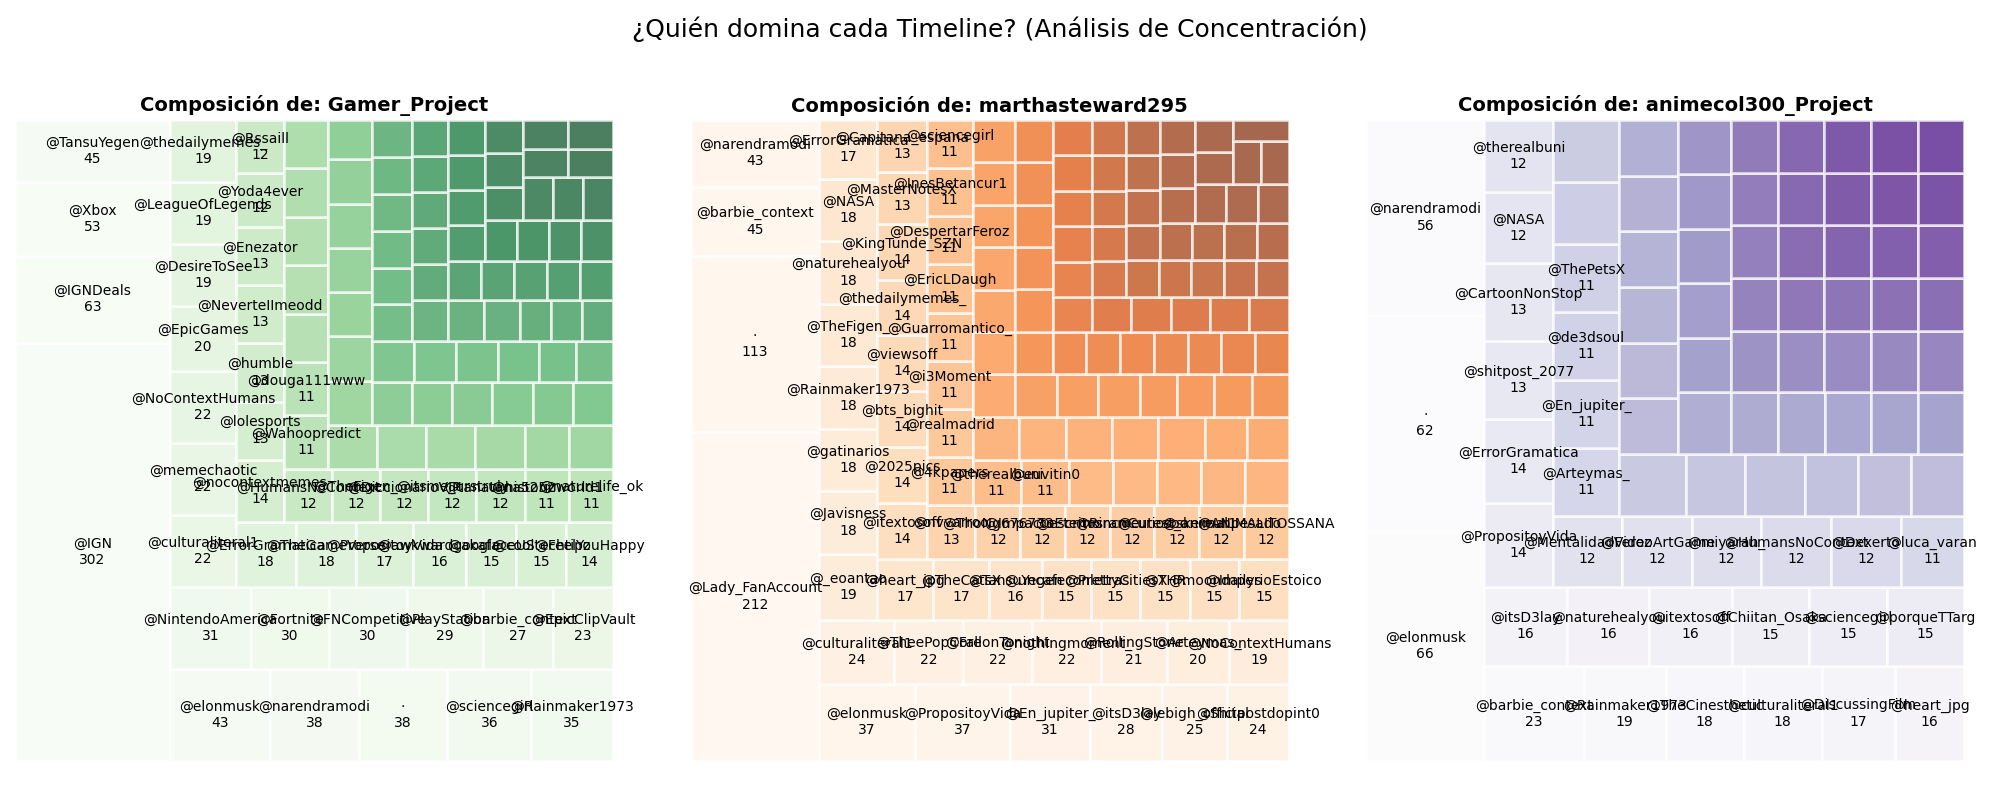

In [11]:
import matplotlib.pyplot as plt
import squarify 
import seaborn as sns

# 1. Filtramos para ver solo a los autores que realmente pesan (ej. más de 5 tweets)
df_filt = df.groupby(['account_label', 'author']).size().reset_index(name='count')
df_filt = df_filt[df_filt['count'] > 5]

# 2. Creamos una figura con 3 sub-gráficos (uno por proyecto)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
proyectos = df['account_label'].unique()
paletas = ["Greens", "Oranges", "Purples"] # Un color base para cada cuenta

for i, proyecto in enumerate(proyectos):
    data_proy = df_filt[df_filt['account_label'] == proyecto].sort_values('count', ascending=False)
    
    # Etiquetas solo para los más grandes para evitar el "mugre" visual
    labels = [f"{row['author']}\n{row['count']}" if row['count'] > 10 else "" 
              for _, row in data_proy.iterrows()]
    
    squarify.plot(sizes=data_proy['count'], label=labels, 
                  color=sns.color_palette(paletas[i], len(data_proy)), 
                  alpha=0.7, ax=axes[i], edgecolor="white", linewidth=2)
    
    axes[i].set_title(f"Composición de: {proyecto}", fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("¿Quién domina cada Timeline? (Análisis de Concentración)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()